<a href="https://colab.research.google.com/github/frysushi00/ViTGalaxyClassifier/blob/main/ViTGalaxiesClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CLASSIFYING GALAXIES WITH VISUAL TRANSFORMERS**
> Implementing Visual Transformers to classify galaxies into three classes (Featured, Smooth, Artifact), ViT implements Transformers architecture (self-attention) to sequences of image or called patches without any convlutional layers, instead it used multilayer perceptron (MLP)


**REFERENCES:** <br>
*[ViT for Image Classification](https://colab.research.google.com/github/keras-team/keras-io/blob/master/examples/vision/ipynb/image_classification_with_vision_transformer.ipynb#scrollTo=4sxHEjMWcVxK)* <br>
*[Galaxy Zoo Datasets](https://github.com/mwalmsley/galaxy-datasets/tree/main)*<br>
*[Galaxies Morphological Measurement in DESI](https://ui.adsabs.harvard.edu/abs/2023yCat..75264768W/abstract)*


## SETUP

In [84]:
!pip install transformers galaxy-datasets

In [86]:
import torchgen
from PIL import ImageDraw
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras import ops
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [87]:
from galaxy_datasets import gz_candels

catalog, label_cols = gz_candels(
    root='./gz_candels',
    train=True,
    download=True
)

100%|██████████| 4177120/4177120 [00:00<00:00, 12437686.75it/s]


100%|██████████| 1162980/1162980 [00:00<00:00, 3746495.10it/s]


Using downloaded and verified file: ./gz_candels/candels_images.tar.gz
Extracting ./gz_candels/candels_images.tar.gz to ./gz_candels


## DATASET

In [88]:
df = pd.read_parquet('/content/gz_candels/candels_ortho_train_catalog.parquet')
df

,ra,dec,smooth-or-featured-candels_smooth_fraction,smooth-or-featured-candels_features_fraction,smooth-or-featured-candels_artifact_fraction,smooth-or-featured-candels_total-votes,how-rounded-candels_completely_fraction,how-rounded-candels_in-between_fraction,how-rounded-candels_cigar-shaped_fraction,how-rounded-candels_total-votes,...,spiral-arm-count-candels_cant-tell,bulge-size-candels_none,bulge-size-candels_obvious,bulge-size-candels_dominant,merging-candels_merger,merging-candels_tidal-debris,merging-candels_both,merging-candels_neither,id_str,filename
0,34.481978,-5.195885,0.291667,0.000000,0.708333,24.0,0.857143,0.142857,0.000,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,UDS_14439,UDS_14439.jpg
1,150.088460,2.178708,0.411765,0.117647,0.470588,34.0,0.357143,0.642857,0.000,14.0,...,0.0,0.0,0.0,0.0,3.0,0.0,1.0,14.0,COS_89,COS_89.jpg
2,53.060933,-27.781595,0.277778,0.277778,0.444444,18.0,0.400000,0.600000,0.000,5.0,...,1.0,2.0,0.0,0.0,0.0,0.0,0.0,10.0,GDS_14317,GDS_14317.jpg
3,34.350231,-5.225495,0.472222,0.194444,0.333333,36.0,0.235294,0.764706,0.000,17.0,...,0.0,2.0,2.0,1.0,2.0,2.0,2.0,18.0,UDS_9017,UDS_9017.jpg
4,150.105650,2.269315,0.363636,0.090909,0.545455,22.0,0.500000,0.375000,0.125,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,COS_7477,COS_7477.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39636,150.159240,2.491060,0.394737,0.131579,0.473684,38.0,0.533333,0.466667,0.000,15.0,...,0.0,1.0,1.0,1.0,0.0,1.0,1.0,18.0,COS_24955,COS_24955.jpg
39637,34.464676,-5.138540,0.542857,0.057143,0.400000,35.0,0.684211,0.315789,0.000,19.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,20.0,UDS_26333,UDS_26333.jpg
39638,34.307697,-5.192504,0.233333,0.100000,0.666667,30.0,0.714286,0.285714,0.000,7.0,...,0.0,1.0,0.0,0.0,2.0,0.0,2.0,6.0,UDS_15091,UDS_15091.jpg
39639,150.086460,2.313002,0.435897,0.076923,0.487179,39.0,0.294118,0.705882,0.000,17.0,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,17.0,COS_11168,COS_11168.jpg


In [89]:
df = df.sample(1000, random_state=42)

In [90]:
df['filename']

,filename
25028,COS_27104.jpg
10480,GDS_24097.jpg
19690,COS_24116.jpg
24403,GDS_2234.jpg
198,COS_5615.jpg
...,...
3835,COS_12168.jpg
19530,COS_25849.jpg
18641,UDS_22293.jpg
19723,GDS_14024.jpg


In [91]:
# feature_extractor = ViTFeatureExtractor.from_pretrained('google/vit-base-patch16-224')
# model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

In [92]:
train_catalog_loc = '/content/gz_candels/candels_ortho_train_catalog.parquet'
test_catalog_loc = '/content/gz_candels/candels_ortho_test_catalog.parquet'

train_catalog.to_parquet(train_catalog_loc, index=False)
test_catalog.to_parquet(test_catalog_loc, index=False)

In [93]:
train_catalog, test_catalog = train_test_split(df, test_size=0.2, random_state=42)

In [94]:
IMAGE_DIR = "/content/gz_candels/images"

In [95]:
def load_image(filename):
  filename = tf.strings.join([IMAGE_DIR,"/",filename])
  img = tf.io.read_file(filename)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (72,72))
  img = tf.cast(img, tf.float32)
  return img

In [96]:
label_cols = [
    "smooth-or-featured-candels_smooth_fraction",
    "smooth-or-featured-candels_features_fraction",
    "smooth-or-featured-candels_artifact_fraction",
]

### DATASET SPLITTING

In [97]:
y_train = np.argmax(train_catalog[label_cols].values, axis=1)
y_test = np.argmax(test_catalog[label_cols].values, axis=1)

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_catalog["filename"].values, y_train)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_catalog["filename"].values, y_test)
)

In [98]:
def load_image_label(filename, label):
    img = load_image(filename)
    return img, label

train_ds = (
    train_ds
    .map(load_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

## MODELLING

In [99]:
learning_rate = 0.001
weight_decay = 0.0001
batch_size = 256
num_epochs = 100
image_size = 72
patch_size = 6
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
input_shape = (72,72,3)
num_classes = 3
transformer_units = [
    projection_dim * 2,
    projection_dim,
]
transformer_layers = 8
mlp_head_units = [
    2048,
    1024,
]

### DATA AUGMENTATION

In [100]:
data_augmentation = keras.Sequential(
    [
        layers.Normalization(),
        layers.Resizing(image_size, image_size),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
    ],
    name="data_augmentation",
)
data_augmentation.layers[0].adapt(train_ds.map(lambda img, label: img))

### MLP

In [101]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

### CREATING & ENCODING PATCHES

In [102]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

Image size: 72 X 72
Patch size: 6 X 6
Patches per image: 144
Elements per patch: 108


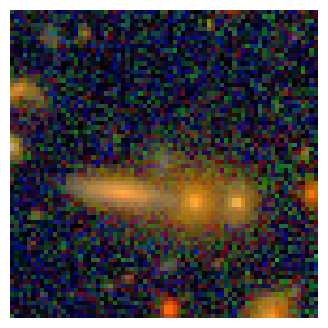

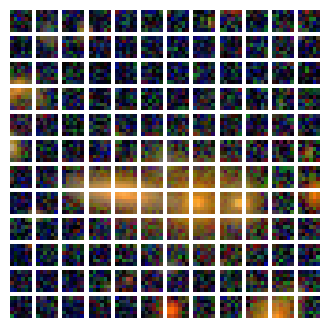

In [103]:
plt.figure(figsize=(4, 4))
images, labels = next(iter(train_ds))
image = images[0]
label = labels[0]
plt.imshow(tf.cast(image, tf.uint8))
plt.axis("off")

resized_image = ops.image.resize(
    ops.convert_to_tensor([image]), size=(image_size, image_size)
)
patches = Patches(patch_size)(tf.expand_dims(image, axis=0))
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = ops.reshape(patch, (patch_size, patch_size, 3))
    plt.imshow(ops.convert_to_numpy(patch_img).astype("uint8"))
    plt.axis("off")

In [104]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config

###CLASSIFIER

In [105]:
def create_vit_classifier():
    inputs = keras.Input(shape=input_shape)
    augmented = data_augmentation(inputs)
    patches = Patches(patch_size)(augmented)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        encoded_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    logits = layers.Dense(num_classes)(features)

    model = keras.Model(inputs=inputs, outputs=logits)
    return model

## TRAINING

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 239ms/step - accuracy: 0.5537 - loss: 3.3752 - top-5-accuracy: 1.0000 - val_accuracy: 0.2300 - val_loss: 2.9474 - val_top-5-accuracy: 1.0000
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.5650 - loss: 1.7627 - top-5-accuracy: 1.0000 - val_accuracy: 0.7550 - val_loss: 0.6609 - val_top-5-accuracy: 1.0000
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.5825 - loss: 1.1051 - top-5-accuracy: 1.0000 - val_accuracy: 0.7200 - val_loss: 0.6937 - val_top-5-accuracy: 1.0000
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.6562 - loss: 0.8613 - top-5-accuracy: 1.0000 - val_accuracy: 0.6950 - val_loss: 0.7763 - val_top-5-accuracy: 1.0000
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.6637 - loss: 0.7812 - top-5-accuracy: 1.0000 - val_accuracy: 0.6900 - val_loss: 0.7173 - val_top-5-accuracy: 1.0000
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 235ms/step - accuracy: 0.6737 - loss: 0.71

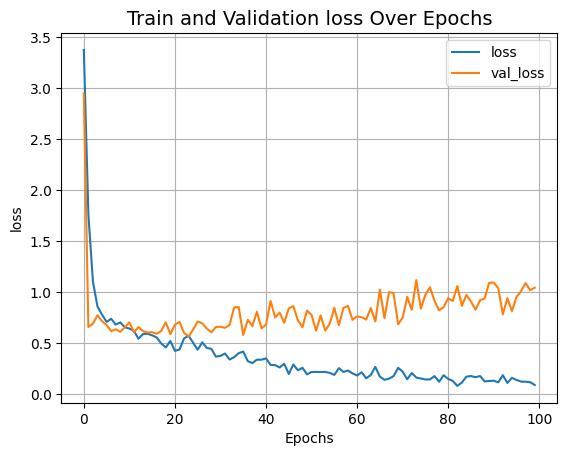

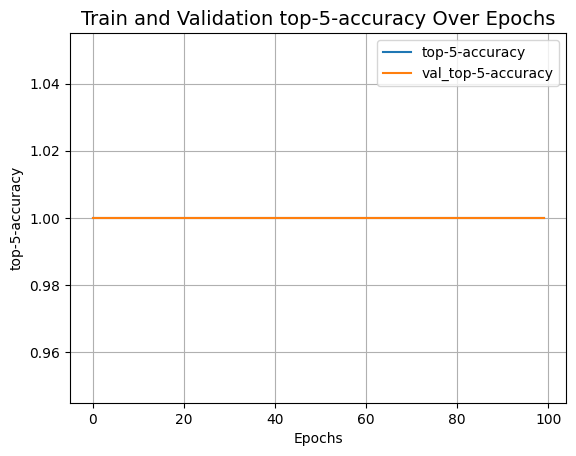

In [106]:
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
        ],
    )
    checkpoint_filepath = "/tmp/checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )
    history = model.fit(
        train_ds,
        validation_data=test_ds,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=[checkpoint_callback],
    )
    model.load_weights(checkpoint_filepath)
    _, accuracy, top_5_accuracy = model.evaluate(test_ds)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")
    print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")
    return history
vit_classifier = create_vit_classifier()
history = run_experiment(vit_classifier)

def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()
plot_history("loss")
plot_history("top-5-accuracy")

## RESULT

In [107]:
y_true = []
y_pred = []
for images, labels in test_ds:
    logits = vit_classifier.predict(images, verbose=0)
    preds = np.argmax(logits, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)
y_true = np.array(y_true)
y_pred = np.array(y_pred)

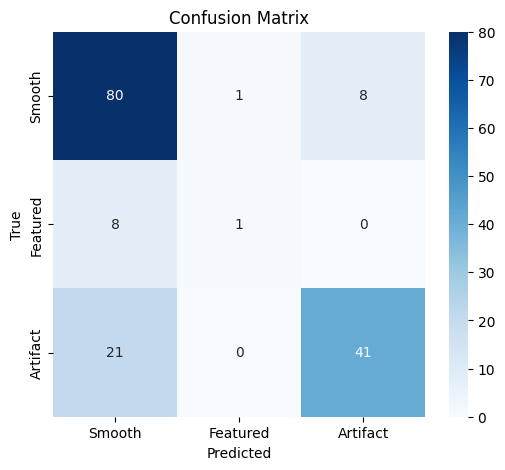

In [108]:
class_names = [
    "Smooth",
    "Featured",
    "Artifact"
]
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [109]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      Smooth       0.83      0.93      0.88       137
    Featured       0.50      0.12      0.20         8
    Artifact       0.78      0.64      0.70        55

    accuracy                           0.81       200
   macro avg       0.70      0.56      0.59       200
weighted avg       0.80      0.81      0.80       200



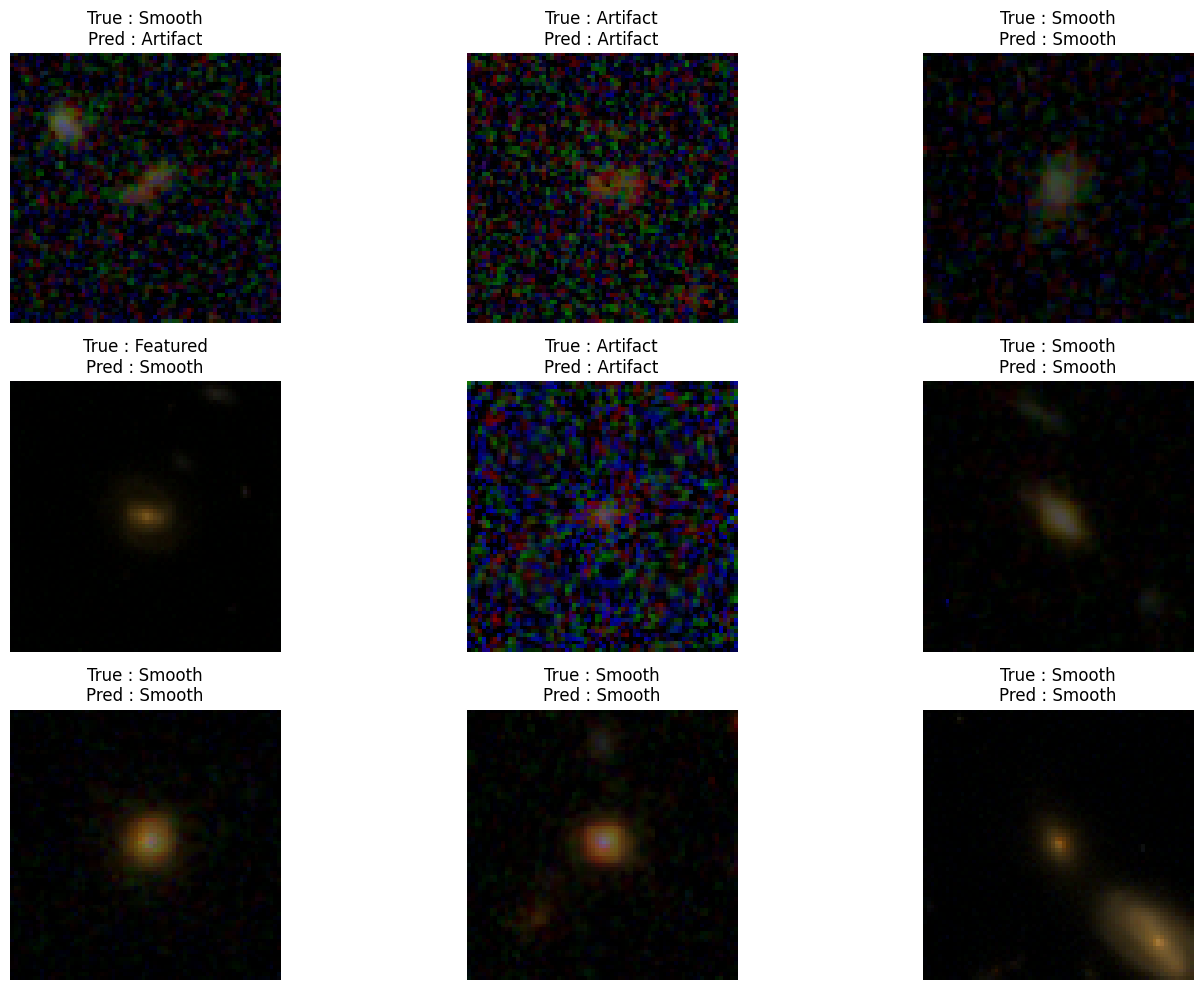

In [110]:
plt.figure(figsize=(15,10))
images, labels = next(iter(test_ds))
pred = vit_classifier.predict(images, verbose=0)
pred = np.argmax(pred, axis=1)
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(
        f"True : {class_names[int(labels[i])]}\n"
        f"Pred : {class_names[pred[i]]}"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()